<a href="https://colab.research.google.com/github/eshhha/ADULT_INCOME___PREDICTION/blob/SVM-%26-NAIVE-BAYES/Adult_Income_prediction(preprocessing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Esha

In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#LIBRARIES

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

#READ DATASET

In [82]:
filepath = '/content/drive/MyDrive/AI ML Course/Data/adult.csv'
df_adult = pd.read_csv(filepath)
df_adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#EDA(Exploratory Data Analysis)

In [83]:
# Check the number of rows and columns in the dataset
df_adult.shape

(48842, 15)

In [84]:
# Display summary statistics of the numerical columns
df_adult.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [85]:
# Display information about the DataFrame
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [86]:
# Count the occurrences of each unique row in the DataFrame
df_adult.value_counts()

age  workclass  fnlwgt  education     educational-num  marital-status      occupation         relationship   race   gender  capital-gain  capital-loss  hours-per-week  native-country  income
25   Private    308144  Bachelors     13               Never-married       Craft-repair       Not-in-family  White  Male    0             0             40              Mexico          <=50K     3
                195994  1st-4th       2                Never-married       Priv-house-serv    Not-in-family  White  Female  0             0             40              Guatemala       <=50K     3
21   Private    243368  Preschool     1                Never-married       Farming-fishing    Not-in-family  White  Male    0             0             50              Mexico          <=50K     3
39   Private    184659  HS-grad       9                Married-civ-spouse  Machine-op-inspct  Husband        White  Male    0             0             40              United-States   <=50K     2
45   Private    82797   Bachelors     13               Married-civ-spouse  Exec-managerial    Husband        White  Male    0             0             45              United-States   >50K      2
                                                                                                                                                                                                 ..
31   Private    156464  10th          6                Divorced            Other-service      Not-in-family  White  Male    0             0             40              United-States   <=50K     1
                        Bachelors     13               Never-married       Prof-specialty     Own-child      White  Male    0             0             25              United-States   <=50K     1
                156493  HS-grad       9                Never-married       Prof-specialty     Own-child      White  Male    0             0             40              United-States   <=50K     1
                        Some-college  10               Married-civ-spouse  Exec-managerial    Husband        White  Male    0             0             40              United-States   >50K      1
                152940  Some-college  10               Married-civ-spouse  Craft-repair       Husband        White  Male    0             0             40              United-States   <=50K     1
Name: count, Length: 48790, dtype: int64

In [87]:
# Count the total number of duplicate rows in the DataFrame
df_adult.duplicated().sum()

np.int64(52)

In [88]:
# Count the number of missing values in each column
df_adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


##PLOTS

In [89]:
# collecting numerical columns
num_cols = []
# collecting categorical columns
cat_cols = []

In [90]:
# Select the names of all numerical columns (integer and float data types)
num_cols = df_adult.select_dtypes(include=['int','float']).columns
# Select the names of all categorical columns (object and boolean data types)
cat_cols = df_adult.select_dtypes(include=['object','bool']).columns

In [91]:
# Display the names of the numerical columns
num_cols

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [92]:
# Display the names of the categorical columns
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

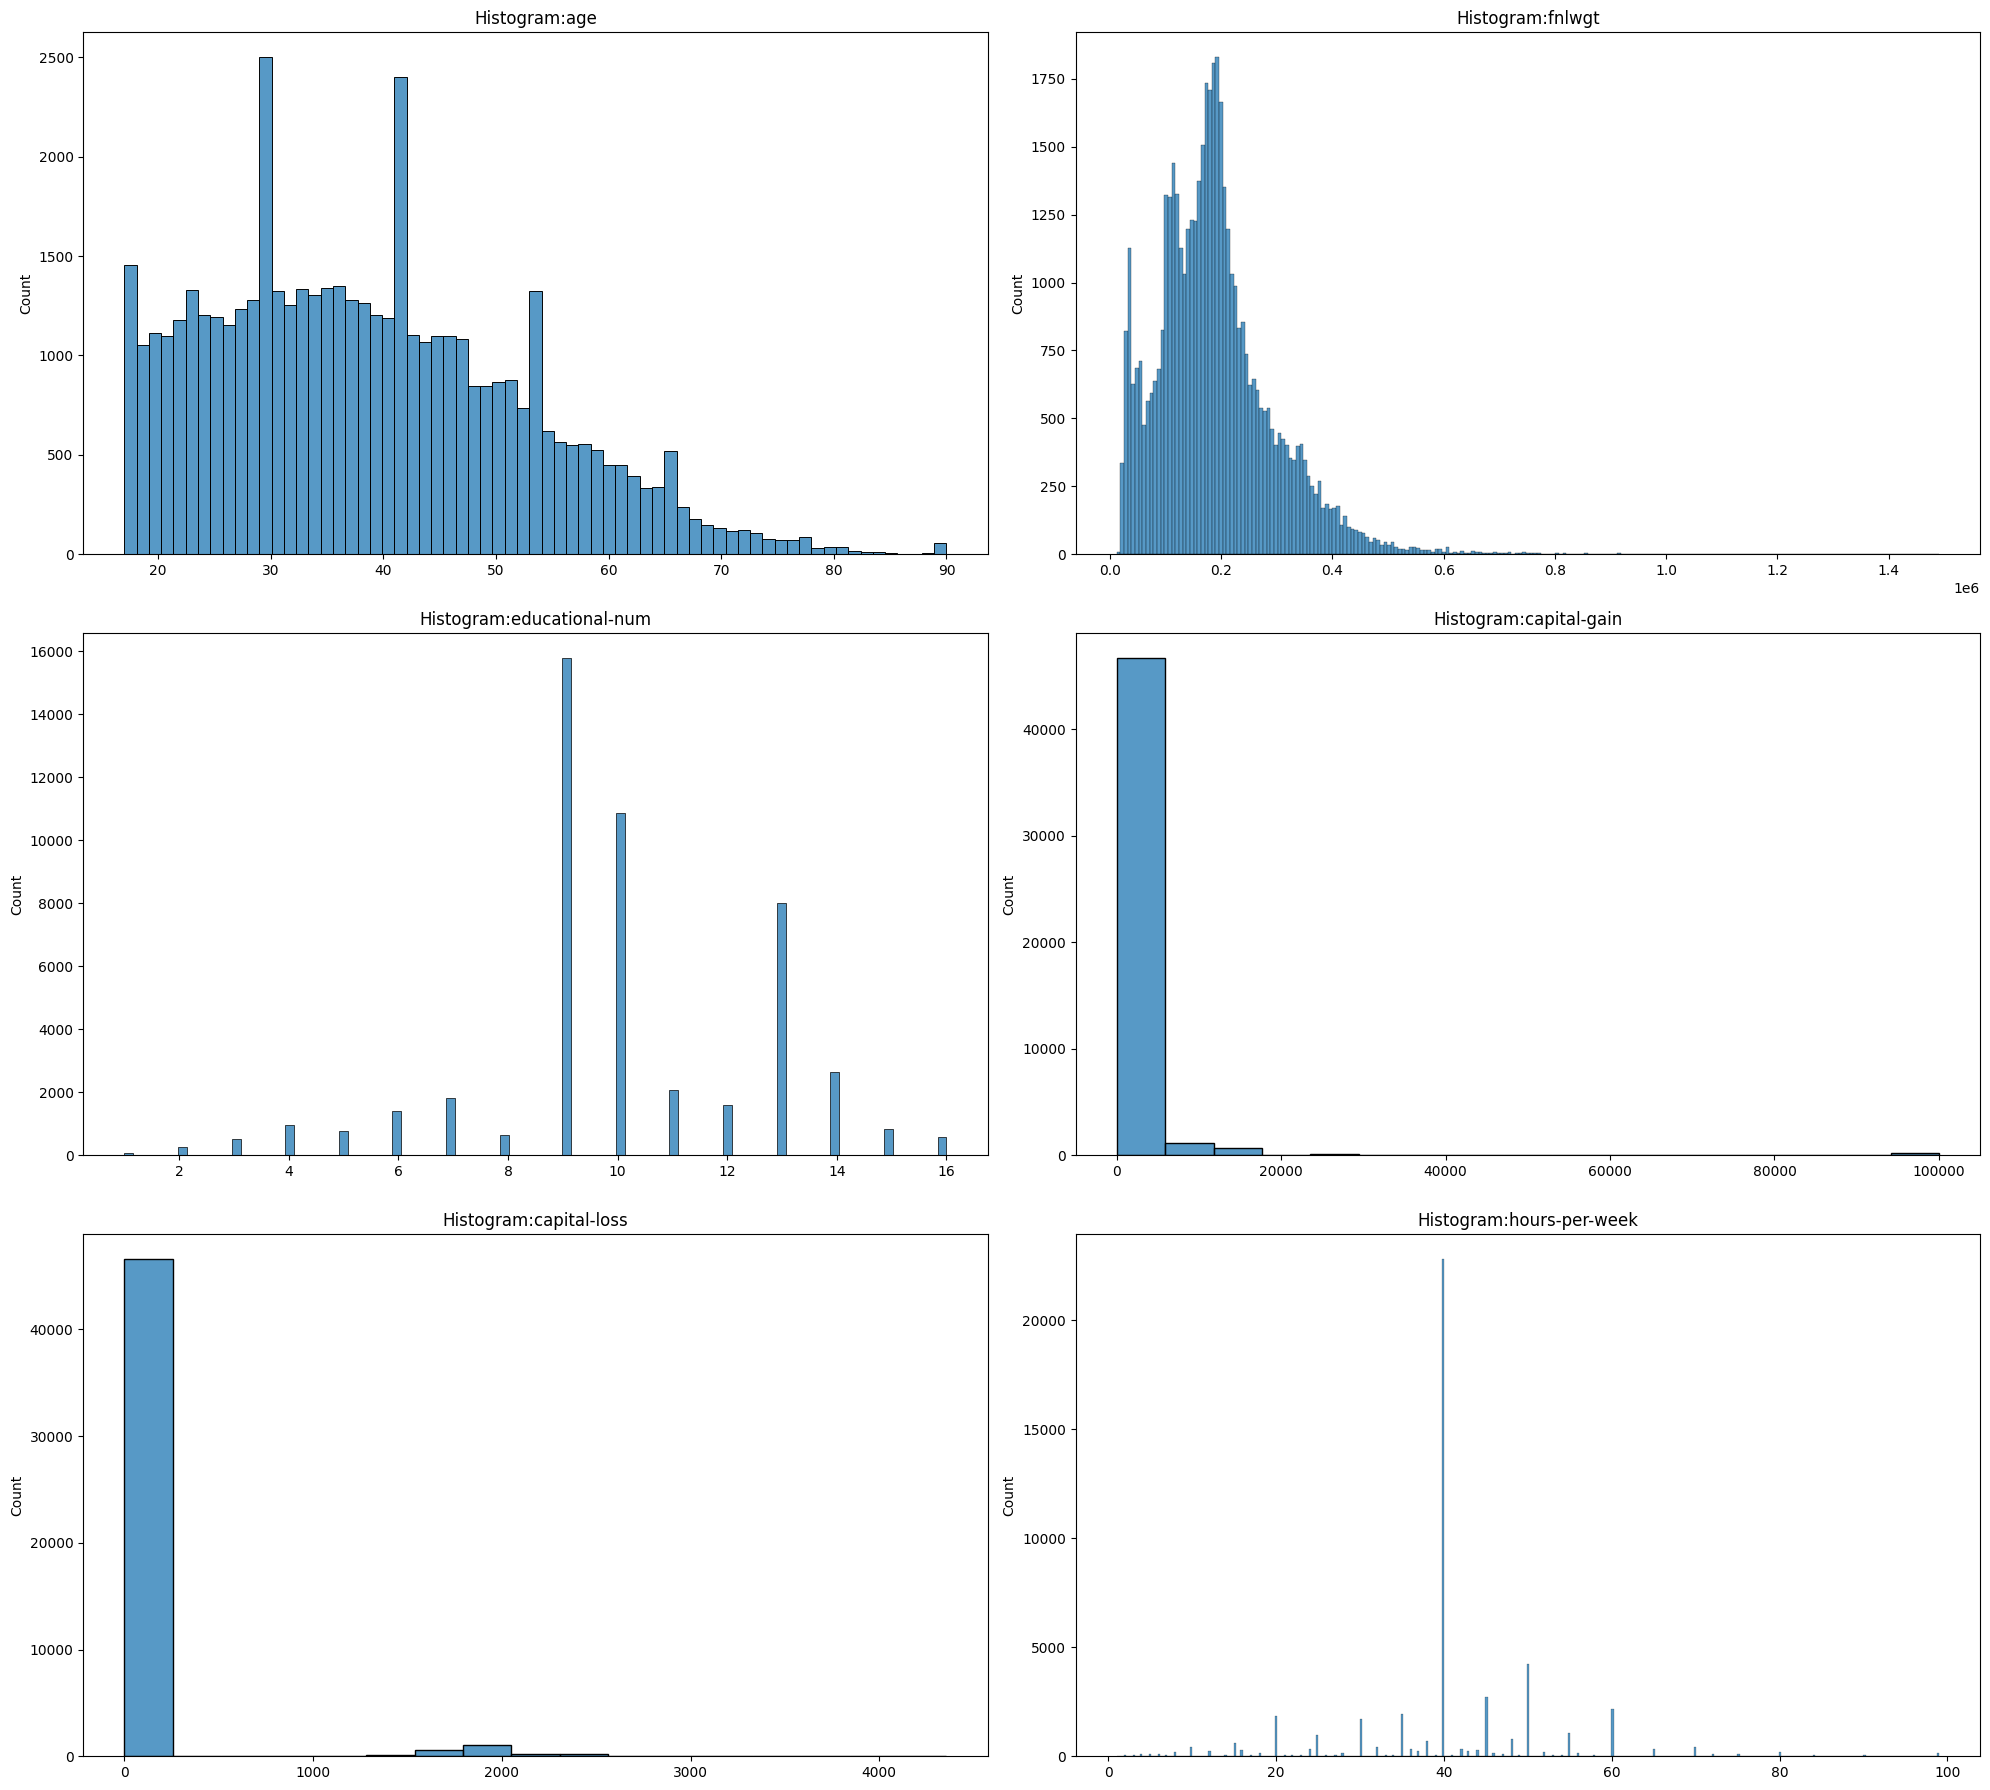

In [93]:
# Create histograms for each numerical column to understand the distribution of values
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.histplot(df_adult[col])
  plt.title(f'Histogram:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

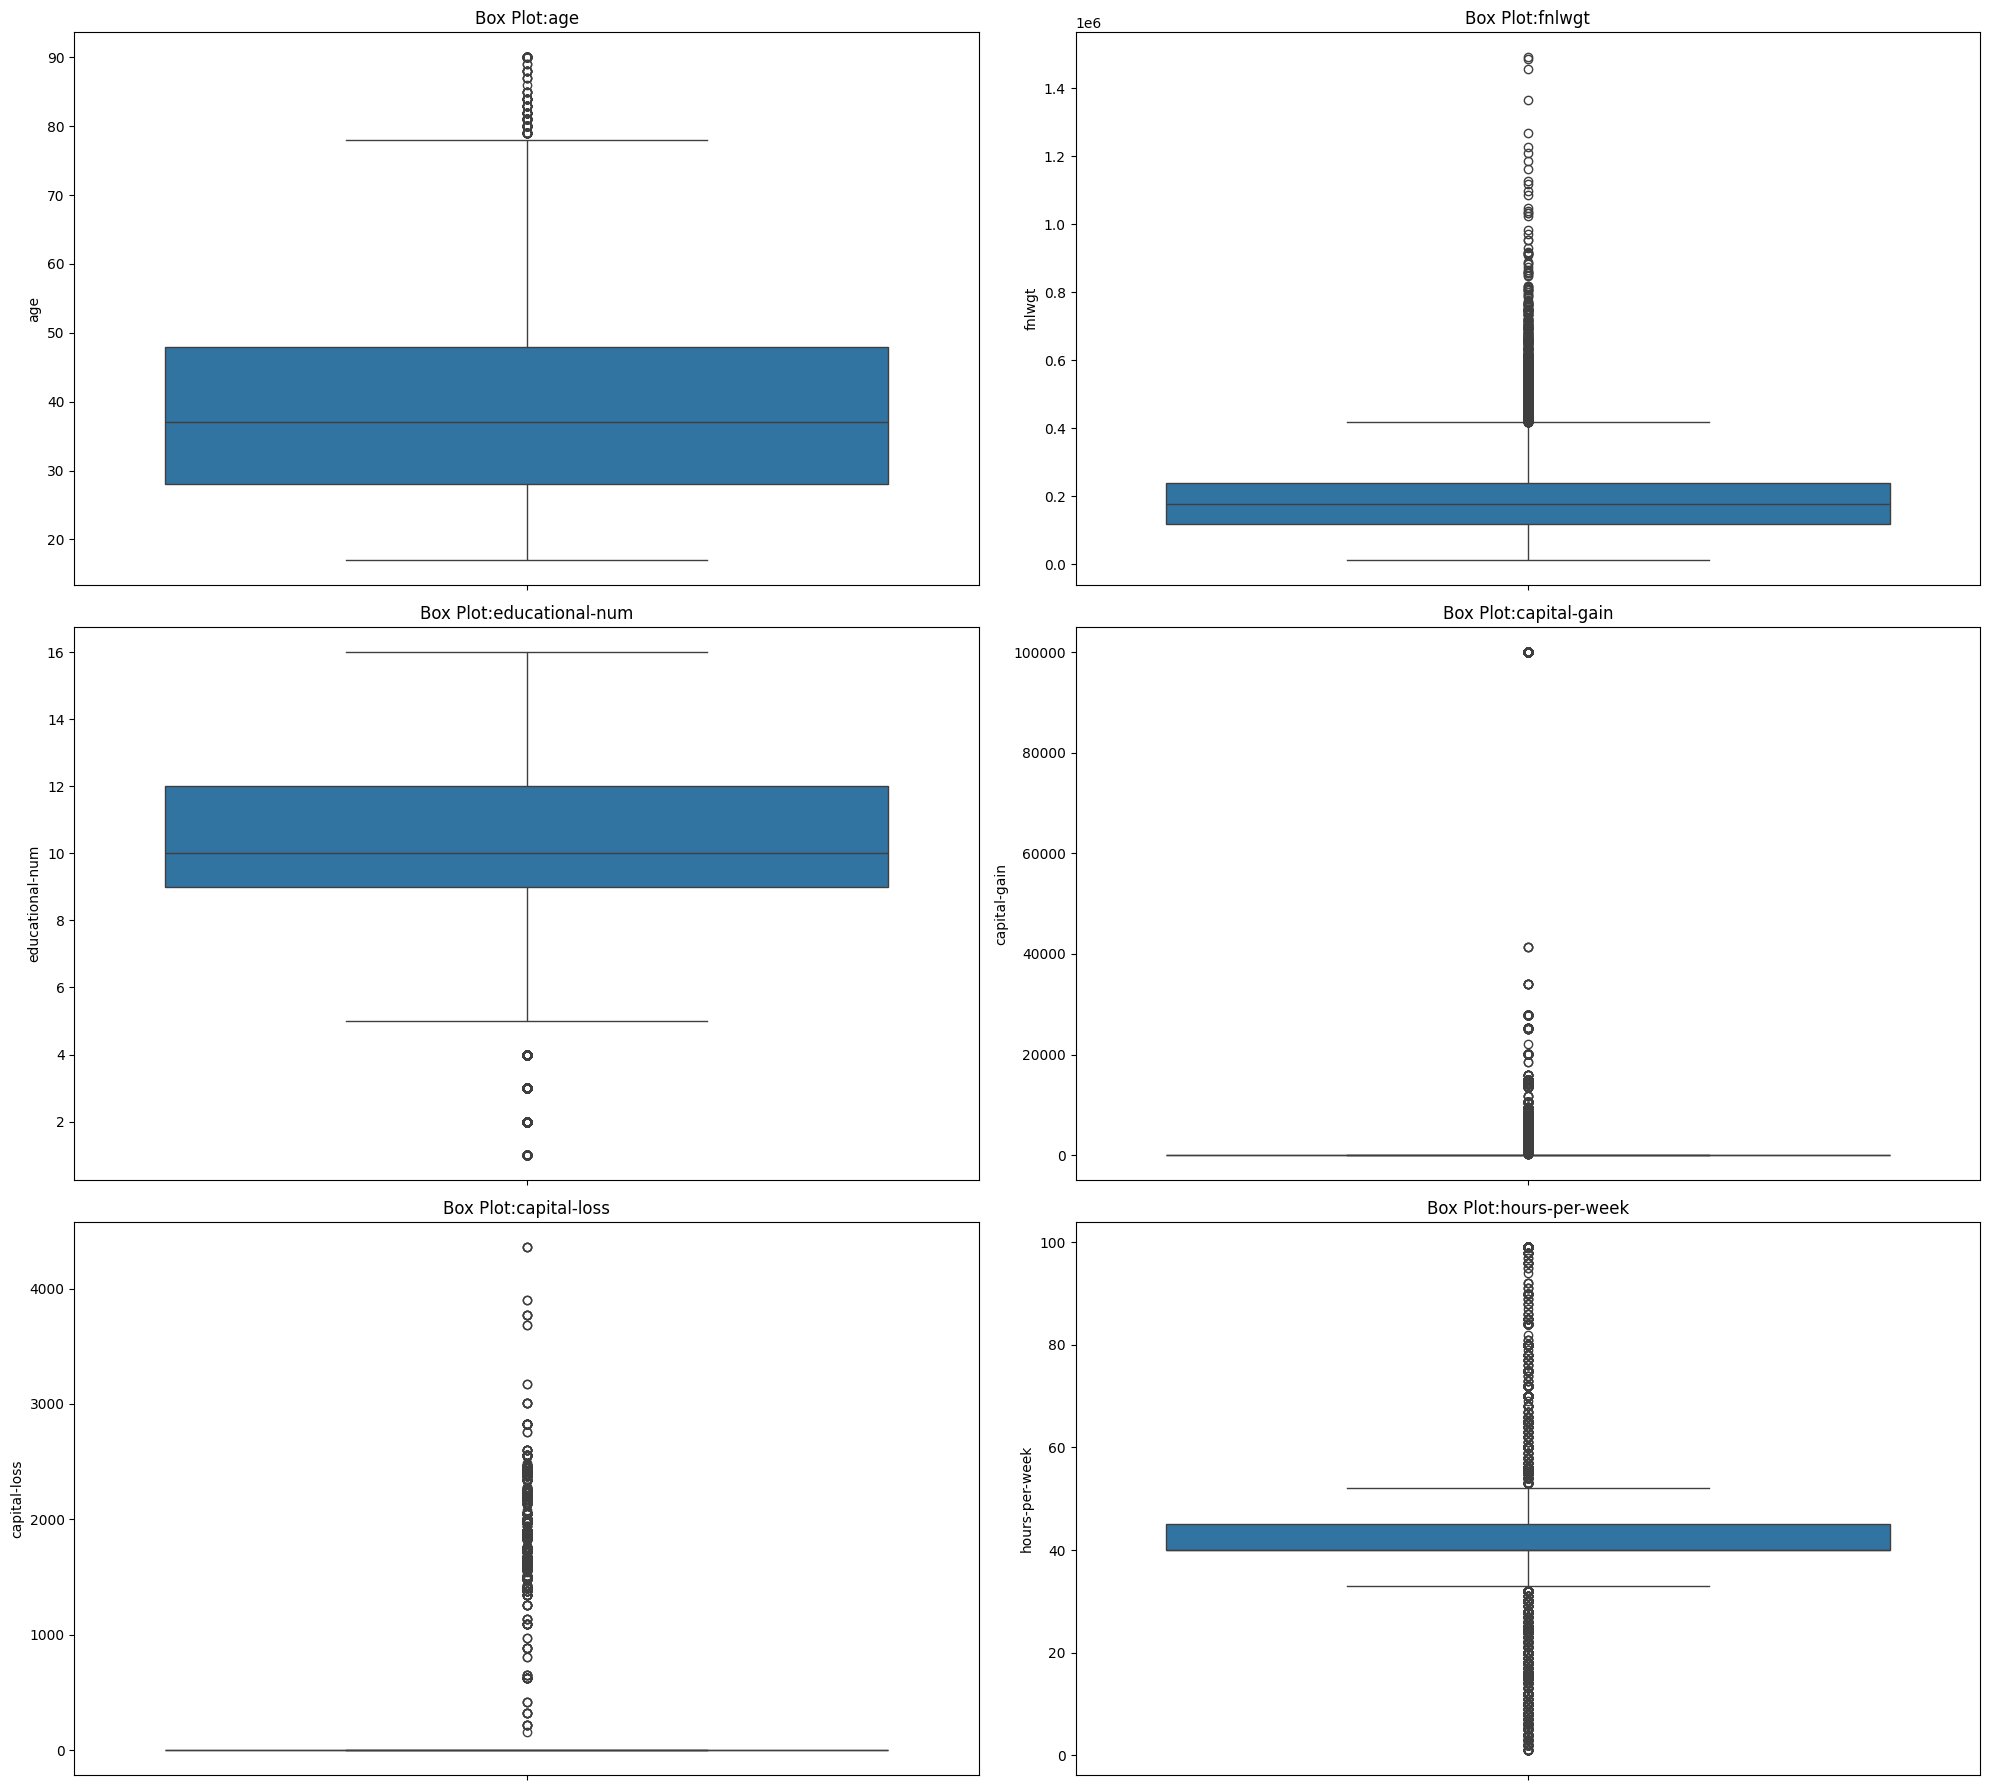

In [94]:
# Create box plots for all numerical features to detect potential outliers
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

###Correlation Matrix

In [95]:
#Identify relationships between numerical features.
corr_matrix = df_adult[num_cols].corr()
corr_matrix


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519
educational-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000


Text(0.5, 1.0, 'Correlation heatmap')

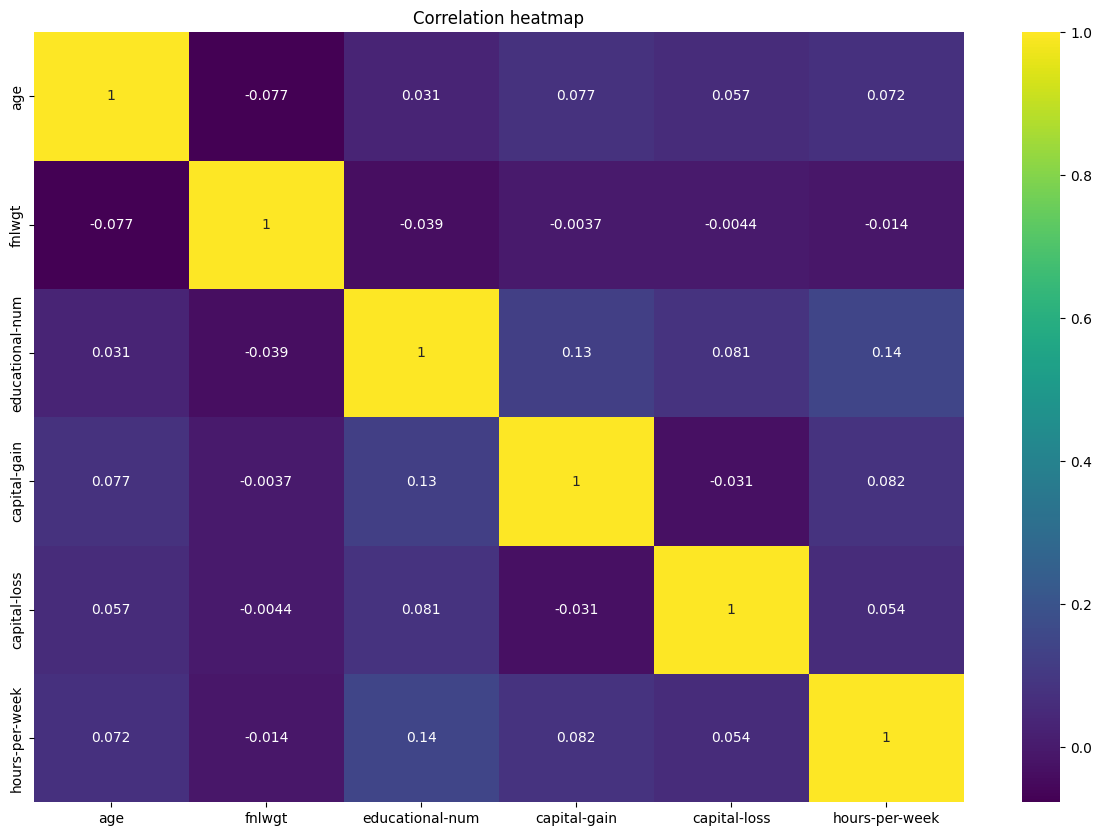

In [96]:
plt.figure(figsize =(15,10))
sns.heatmap(corr_matrix,annot = True,cmap = 'viridis',fmt = '.2g')
plt.title('Correlation heatmap')

#PREPROCESSING

###Muhammed Naif

##Data Cleaning

In [97]:
# Observation from EDA:
# df_adult.isna().sum()` showed 0 missing values.

# Hypothesis:
# The dataset may use "?" strings to represent missing values
# instead of standard NaN, causing pandas to miss them.

# Approach:
# 1. Verify if "?" exists in the data
# 2. If yes, convert them to NaN
# 3. Analyze the missing pattern
# 4. Decide filling strategy
# 5. Apply and verify

##Missing Value Handling

In [98]:
for column in df_adult.columns:
    # Only check object (text) columns
    if df_adult[column].dtype == 'object':
        # Count "?" occurrences
        question_count = (df_adult[column] == '?').sum()

        # Only print if "?" found
        if question_count > 0:
            print(f"{column}: {question_count} '?' values found")

workclass: 2799 '?' values found
occupation: 2809 '?' values found
native-country: 857 '?' values found


In [99]:
# Now that we confirmed "?" exists, replace them with NaN
# This allows pandas to detect them as proper missing values

# Replace all "?" values with NaN across entire DataFrame
df_adult = df_adult.replace('?', np.nan)

In [100]:
# --- Verify conversion worked ---
# Check missing values using standard method now

# Get counts of missing values
missing_counts = df_adult.isna().sum()

In [101]:
# Show only columns WITH missing values
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

workclass         2799
occupation        2809
native-country     857
dtype: int64


In [102]:
# Calculate percentage

missing_percent = (missing_counts / len(df_adult)) * 100
print(missing_percent.round(2))

workclass         5.73
occupation        5.75
native-country    1.75
dtype: float64


In [103]:
# Show mode values for context
for col in ['workclass', 'occupation', 'native-country']:
    mode_val = df_adult[col].mode()[0]
    mode_count = (df_adult[col] == mode_val).sum()
    mode_pct = (mode_count / df_adult[col].notna().sum()) * 100

    print(f"{col}:")
    print(f"  Mode value: '{mode_val}'")
    print(f"  Represents: {mode_pct:.1f}% of non-missing data")
    print()

workclass:
  Mode value: 'Private'
  Represents: 73.6% of non-missing data

occupation:
  Mode value: 'Prof-specialty'
  Represents: 13.4% of non-missing data

native-country:
  Mode value: 'United-States'
  Represents: 91.3% of non-missing data



I am using a data-driven decision. When the mode represents a strong majority (over 70%), using mode is safe as it reflects the true dominant category. However, for occupation, the mode 'Prof-specialty' only represents 13.4% of data. Filling 2,809 missing values with it would artificially inflate this category, distorting the distribution. Instead, I used 'Unknown' to preserve the information that data was missing without biasing the model.

In [104]:
# Fill workclass with mode
workclass_mode = df_adult['workclass'].mode()[0]
df_adult['workclass'].fillna(workclass_mode, inplace=True)
print(f"✅ workclass filled with mode: '{workclass_mode}'")

✅ workclass filled with mode: 'Private'


In [105]:
# ill occupation with "Unknown"
df_adult['occupation'].fillna('Unknown', inplace=True)
print(f"✅ occupation filled with 'Unknown'")

✅ occupation filled with 'Unknown'


In [106]:
# Fill native-country with mode
country_mode = df_adult['native-country'].mode()[0]
df_adult['native-country'].fillna(country_mode, inplace=True)
print(f"✅ native-country filled with mode: '{country_mode}'")

✅ native-country filled with mode: 'United-States'


In [107]:
# Final Verification
total_missing = df_adult.isna().sum().sum()
print(f"Total missing values remaining: {total_missing}")

Total missing values remaining: 0


##Duplication Removal

In [108]:
current_duplicates = df_adult.duplicated().sum()
current_rows = df_adult.shape[0]

print(f"Current rows: {current_rows}")
print(f"Duplicate rows: {current_duplicates}")
print(f"Unique rows: {current_rows - current_duplicates}")

Current rows: 48842
Duplicate rows: 52
Unique rows: 48790


In [109]:
# --- Remove Duplicate Rows ---
# Strategy: keep='first' → keeps first occurrence, removes others
# Reason: Duplicates add bias; only 52 rows (0.1% loss) is acceptable

In [110]:
# Show before state
print(f"Rows BEFORE removal: {df_adult.shape[0]}")

Rows BEFORE removal: 48842


In [111]:
# Remove duplicates
df_adult = df_adult.drop_duplicates(keep='first')

In [112]:
# Show after state
print(f"Rows AFTER removal: {df_adult.shape[0]}")
print(f"Duplicates removed: {52}")

Rows AFTER removal: 48790
Duplicates removed: 52


In [113]:
# Verify no duplicates remain
remaining_duplicates = df_adult.duplicated().sum()
print(f"\nRemaining duplicates: {remaining_duplicates}")


Remaining duplicates: 0


###Outlier Handling

In [114]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    count = len(outliers)
    percentage = (count / len(df)) * 100

    return count, lower_bound, upper_bound, percentage

In [115]:
# --- Numerical columns to check ---
numerical_cols = ['age', 'fnlwgt', 'educational-num',
                  'capital-gain', 'capital-loss', 'hours-per-week']

In [116]:
# --- Detect outliers in each column ---
print("--- Outlier Detection Report ---\n")
print(f"{'Column':<20} {'Outliers':<10} {'% of Data':<12} {'Lower':<15} {'Upper':<15}")
print("-" * 72)

for col in numerical_cols:
    count, lower, upper, pct = detect_outliers_iqr(df_adult, col)
    print(f"{col:<20} {count:<10} {pct:<12.2f} {lower:<15.2f} {upper:<15.2f}")

--- Outlier Detection Report ---

Column               Outliers   % of Data    Lower           Upper          
------------------------------------------------------------------------
age                  215        0.44         -2.00           78.00          
fnlwgt               1453       2.98         -62521.88       417683.12      
educational-num      1787       3.66         4.50            16.50          
capital-gain         4035       8.27         0.00            0.00           
capital-loss         2282       4.68         0.00            0.00           
hours-per-week       13486      27.64        32.50           52.50          


In [117]:
# Outlier Handling: Cap Using IQR Method
# Strategy: Cap outliers in columns where IQR gives valid bounds
# Skip: capital-gain and capital-loss (zero-inflated, IQR returns 0-0)

In [118]:
# Columns where capping makes sense
cap_columns = ['age', 'fnlwgt', 'educational-num', 'hours-per-week']

In [119]:
# Loop through each column and cap outliers
for col in cap_columns:
    # Calculate IQR bounds
    Q1 = df_adult[col].quantile(0.25)
    Q3 = df_adult[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values above upper bound
    df_adult[col] = np.where(df_adult[col] > upper_bound, upper_bound, df_adult[col])

    # Cap values below lower bound (if applicable)
    df_adult[col] = np.where(df_adult[col] < lower_bound, lower_bound, df_adult[col])

    print(f"✅ {col}: Capped at [{lower_bound:.2f}, {upper_bound:.2f}]")

✅ age: Capped at [-2.00, 78.00]
✅ fnlwgt: Capped at [-62521.88, 417683.12]
✅ educational-num: Capped at [4.50, 16.50]
✅ hours-per-week: Capped at [32.50, 52.50]


In [120]:
# Capital-gain and capital-loss were skipped because 75% of
# values are 0, causing IQR to return invalid 0-0 bounds.

In [121]:
print("--- Final Dataset Status ---\n")
print(f"Total rows: {df_adult.shape[0]}")
print(f"Total columns: {df_adult.shape[1]}")
print(f"Missing values: {df_adult.isna().sum().sum()}")
print(f"Duplicate rows: {df_adult.duplicated().sum()}")

print("\n--- Data Types ---")
print(df_adult.dtypes.value_counts())

print("\n✅ Dataset ready for transformations!")

--- Final Dataset Status ---

Total rows: 48790
Total columns: 15
Missing values: 0
Duplicate rows: 34

--- Data Types ---
object     9
float64    4
int64      2
Name: count, dtype: int64

✅ Dataset ready for transformations!


In [122]:
# --- Save cleaned dataset for team members ---
# This file will be used for encoding, scaling, and modeling

df_adult.to_csv('adult_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'adult_cleaned.csv'")
print("   Ready for team member to continue with transformations!")

✅ Cleaned dataset saved as 'adult_cleaned.csv'
   Ready for team member to continue with transformations!


#TRANSFORMATIONS

##Encoding

### Tojo

###Removing Independent Columns

In [123]:
df_adult.drop(columns=['race','educational-num','native-country'],inplace=True)

In [124]:
df_adult['income'].unique() # taking unique items in each column

array(['<=50K', '>50K'], dtype=object)

In [125]:
df_adult['gender'].unique() # taking unique items in each column

array(['Male', 'Female'], dtype=object)

In [126]:
# Label Encoding is used for binary categorical columns
# 'income' has only two categories
# 'gender' also has only two categories

In [127]:
label_enc = LabelEncoder()

df_adult['income'] = label_enc.fit_transform(df_adult['income'])
df_adult['gender'] = label_enc.fit_transform(df_adult['gender'])

In [128]:
df_adult.head(3) # label encoding done

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income
0,25.0,Private,226802.0,11th,Never-married,Machine-op-inspct,Own-child,1,0,0,40.0,0
1,38.0,Private,89814.0,HS-grad,Married-civ-spouse,Farming-fishing,Husband,1,0,0,50.0,0
2,28.0,Local-gov,336951.0,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,1,0,0,40.0,1


In [129]:
df_adult['education'].unique()  # taking unique items in each column

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [130]:
# Ordinal Encoding is used because education categories

In [131]:
# OrdinalEncoder with the specified category order
edu_order = [['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm',
                    'Bachelors', 'Masters', 'Prof-school', 'Doctorate']]

ordinal_encoder = OrdinalEncoder(categories=edu_order)

# Apply Ordinal Encoding to the education column
df_adult[['education']] = ordinal_encoder.fit_transform(df_adult[['education']])

In [132]:
df_adult.head(3) # after ordinal encoding

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income
0,25.0,Private,226802.0,6.0,Never-married,Machine-op-inspct,Own-child,1,0,0,40.0,0
1,38.0,Private,89814.0,8.0,Married-civ-spouse,Farming-fishing,Husband,1,0,0,50.0,0
2,28.0,Local-gov,336951.0,11.0,Married-civ-spouse,Protective-serv,Husband,1,0,0,40.0,1


In [133]:
df_adult['workclass'].unique()  # taking unique items in each column

array(['Private', 'Local-gov', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [134]:
# the order for workclass categories
workclass_order = [['Never-worked', 'Without-pay', 'Private', 'Self-emp-not-inc', 'Self-emp-inc', 'Local-gov', 'State-gov','Federal-gov']]

# Create the OrdinalEncoder with the specified category order
ordinal_encoder = OrdinalEncoder(categories=workclass_order)

# Apply Ordinal Encoding to the workclass column
df_adult[['workclass']] = ordinal_encoder.fit_transform(df_adult[['workclass']])

In [135]:
df_adult.head(3) # after ordinal encoding

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income
0,25.0,2.0,226802.0,6.0,Never-married,Machine-op-inspct,Own-child,1,0,0,40.0,0
1,38.0,2.0,89814.0,8.0,Married-civ-spouse,Farming-fishing,Husband,1,0,0,50.0,0
2,28.0,5.0,336951.0,11.0,Married-civ-spouse,Protective-serv,Husband,1,0,0,40.0,1


In [136]:
df_adult['marital-status'].unique()  # taking unique items in each column

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [137]:
df_adult['occupation'].unique() # taking unique items in each column

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Unknown', 'Other-service', 'Prof-specialty', 'Craft-repair',
       'Adm-clerical', 'Exec-managerial', 'Tech-support', 'Sales',
       'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners',
       'Armed-Forces'], dtype=object)

In [138]:
df_adult['relationship'].unique() # taking unique items in each column

array(['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
       'Other-relative'], dtype=object)

In [139]:
# these columns are not having proper order so used the one hot encoding method
one_hot_cols = ['marital-status', 'occupation', 'relationship']
df_ohc = pd.get_dummies(
    df_adult,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int
)

In [140]:
df_ohc.head(3) # after onehot encoding

,age,workclass,fnlwgt,education,gender,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unknown,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,25.0,2.0,226802.0,6.0,1,0,0,40.0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,38.0,2.0,89814.0,8.0,1,0,0,50.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28.0,5.0,336951.0,11.0,1,0,0,40.0,1,0,...,1,0,0,0,0,0,0,0,0,0


In [141]:
print("Before encoding:", df_adult.shape)
print("After encoding:", df_ohc.shape)

Before encoding: (48790, 12)
After encoding: (48790, 34)


In [142]:
# After One-Hot Encoding, the number of columns increased from 12 to 34

In [143]:
df_ohc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 34 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48790 non-null  float64
 1   workclass                             48790 non-null  float64
 2   fnlwgt                                48790 non-null  float64
 3   education                             48790 non-null  float64
 4   gender                                48790 non-null  int64  
 5   capital-gain                          48790 non-null  int64  
 6   capital-loss                          48790 non-null  int64  
 7   hours-per-week                        48790 non-null  float64
 8   income                                48790 non-null  int64  
 9   marital-status_Married-AF-spouse      48790 non-null  int64  
 10  marital-status_Married-civ-spouse     48790 non-null  int64  
 11  marital-status_Marri

#Data Splitting

In [144]:
# Data Splitting

y = df_ohc['income']
X = df_ohc.drop('income',axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,    # training 80% and testing 20%
    random_state=42     # used to get same random states fot testing
)

#Scaling

In [145]:
# Display all column names
df_ohc.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'income',
       'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occupation_Priv-house-serv',
       'occupation_Prof-specialty', 'occupation_Protective-serv',
       'occupation_Sales', 'occupation_Tech-support',
       'occupation_Transport-moving', 'occupation_Unknown',
       'relationship_Not-in-family', 'relationship_Other-relative',
       'relationship_Own-child', 'relationship_Unmarried',
       'relationship_Wife'],
      dtype='object')

In [146]:
# These columns contain large numerical values and need scaling
scale_cols = ['age', 'fnlwgt', 'capital-gain', 'capital-loss',
              'hours-per-week']

In [147]:
# Create StandardScaler object
scaler = StandardScaler()

In [148]:
# Scale the selected columns
df_ohc[scale_cols] = scaler.fit_transform(df_ohc[scale_cols])

In [149]:
# Display first 3 rows
df_ohc.head(3)

,age,workclass,fnlwgt,education,gender,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unknown,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,-0.999931,2.0,0.419962,6.0,1,-0.144882,-0.217248,-0.193066,0,0,...,0,0,0,0,0,0,0,1,0,0
1,-0.046078,2.0,-1.017118,8.0,1,-0.144882,-0.217248,1.423574,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.779811,5.0,1.575485,11.0,1,-0.144882,-0.217248,-0.193066,1,0,...,1,0,0,0,0,0,0,0,0,0


In [150]:
# Check if scaling worked correctly
df_ohc[scale_cols].describe()

,age,fnlwgt,capital-gain,capital-loss,hours-per-week
count,4.879000e+04,4.879000e+04,4.879000e+04,4.879000e+04,4.879000e+04
mean,1.278657e-16,1.479630e-16,-3.029164e-17,-4.077720e-17,8.737972e-18
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.586917e+00,-1.830440e+00,-1.448823e-01,-2.172482e-01,-1.405545e+00
25%,-7.798110e-01,-7.260995e-01,-1.448823e-01,-2.172482e-01,-1.930657e-01
50%,-1.194515e-01,-9.054525e-02,-1.448823e-01,-2.172482e-01,-1.930657e-01
75%,6.876545e-01,5.333041e-01,-1.448823e-01,-2.172482e-01,6.152541e-01
max,2.888853e+00,2.422410e+00,1.326731e+01,1.058619e+01,1.827734e+00


In [151]:
print("Before scaling:")
print(df_adult[scale_cols].head())

print("\nAfter scaling:")
print(df_ohc[scale_cols].head())

Before scaling:
    age    fnlwgt  capital-gain  capital-loss  hours-per-week
0  25.0  226802.0             0             0            40.0
1  38.0   89814.0             0             0            50.0
2  28.0  336951.0             0             0            40.0
3  44.0  160323.0          7688             0            40.0
4  18.0  103497.0             0             0            32.5

After scaling:
        age    fnlwgt  capital-gain  capital-loss  hours-per-week
0 -0.999931  0.419962     -0.144882     -0.217248       -0.193066
1 -0.046078 -1.017118     -0.144882     -0.217248        1.423574
2 -0.779811  1.575485     -0.144882     -0.217248       -0.193066
3  0.394161 -0.277440      0.886257     -0.217248       -0.193066
4 -1.513544 -0.873576     -0.144882     -0.217248       -1.405545


In [152]:
print("Shape after scaling:", df_ohc.shape)

Shape after scaling: (48790, 34)


In [153]:
# Scaling is performed to bring all numerical columns to the same range

# Columns with very large values can dominate ML models

# StandardScaler converts data using:
# z = (x - mean) / standard deviation

# After scaling:
# Mean becomes approximately 0
# Standard deviation becomes approximately 1

#Model Building

### Tojo

### SVM

In [79]:
# build model object
svm_obj = SVC()

# train model
svm_obj.fit(X_train, y_train)

# make predictions using the model
y_pred_svm = svm_obj.predict(X_test)

# evaluate model performance
svm_accuracy = accuracy_score(y_test, y_pred_svm)

### Naive Bayes

In [162]:
# build model object
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

# make predictions using the model
y_pred_nb = nb_model.predict(X_test)

# evaluate model performance
nb_accuracy = accuracy_score(y_test, y_pred_nb)

In [164]:
# Difference between the models

print("SVM Accuracy : ", svm_accuracy)
print("Naive Bayes : ", nb_accuracy)

SVM Accuracy :  0.7999590079934413
Naive Bayes :  0.7963722074195532
ADA Boost  Accuracy :  0.8240418118466899


In [ ]:
cm = confusion_matrix(y_test,y_pred_svm)
print(cm)
print(classification_report(y_test,y_pred_svm))

In [ ]:
cm = confusion_matrix(y_test,y_pred_nb)
print(cm)
print(classification_report(y_test,y_pred_nb))

### K-fold Cross Validation

In [174]:
kf_obj = KFold(n_splits = 5, shuffle = True)

scores = cross_val_score(DecisionTreeClassifier(), X, y, cv = kf_obj)
print('Cross validation scores:',scores)
# print('Mean of cv scores:', np.mean(scores))
print('Mean of cv scores:', scores.mean())
print('Minimum cv:', scores.min())
print('Maximum cv:', scores.max())
diff = scores.max() - scores.min()
print('Difference b/w min and max cv:', diff)

Cross validation scores: [0.81748309 0.81574093 0.80836237 0.81205165 0.82025005]
Mean of cv scores: 0.814777618364419
Minimum cv: 0.8083623693379791
Maximum cv: 0.8202500512400082
Difference b/w min and max cv: 0.011887681902029046


### grid search cross validation

In [175]:
# Define the parameters you want to check
para_grid = {'criterion': ['gini','entropy'],
             'max_depth': [2,3,4,5,6],
              'min_samples_split': [2,4,6]}

# build the model obj
grid = GridSearchCV(DecisionTreeClassifier(), para_grid, cv = 5, scoring = 'accuracy')


# train the model
grid.fit(X_train, y_train)

print('Best parameters are: ', grid.best_params_)
print('Best cross validation score is: ', grid.best_score_)


# We build the model using the best parameters identified
dT_model_HPT = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, min_samples_split = 2)

# Train the model
dT_model_HPT.fit(X_train, y_train)
# Make predictions using the model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)
# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)
print('Accuracy :', acc_dT_HPT)

Best parameters are:  {'criterion': 'gini', 'max_depth': 6, 'min_samples_split': 6}
Best cross validation score is:  0.8554006155614106
Accuracy : 0.8438204550112728


### Random search cross validation

In [180]:
# Define the parameters to check
para_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6]
}

# Build the model object
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=para_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the model
random_search.fit(X_train, y_train)

# Display the best parameters and score
print('Best parameters are:', random_search.best_params_)
print('Best cross validation score is:', random_search.best_score_)

# Build the model using the best parameters
dT_model_HPT = random_search.best_estimator_

# Make predictions using the model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)

# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)

print('Accuracy:', acc_dT_HPT)

Best parameters are: {'min_samples_split': 2, 'max_depth': 6, 'criterion': 'gini'}
Best cross validation score is: 0.8555799549344435
Accuracy: 0.8557081369133019
